# Bayesian Black-Box Optimisation — Capstone Notebook

This notebook tells the full story of the BBO capstone in one place: the data, the method, the
week-by-week results, and the diagnostics that drove each strategy change.

**The task.** Maximise eight unknown functions (2D–8D, inputs in $[0,1]^d$). Each week I may query
**one point per function** through a portal and receive a single scalar output. There are no gradients and no
formula, only the input/output pairs observed so far.

**How to read this notebook**

1. Load every weekly data snapshot (`data/initial_data`, `data/W1_data` … `data/W11_data`).
2. Summarise the campaign: best-so-far per function, week by week.
3. Define the reusable toolkit (GP surrogate, UCB / EI / PI acquisitions, trust-region search, LOO calibration).
4. Worked examples of the three most important methods: trust-region GP (F8), PI for a hairline peak (F4), line search (F5).
5. Back-test: how accurate was the surrogate's prediction *before* each query was submitted?
6. Final results and lessons.

The per-week scripts that produced each actual submission live in `src/weekly/` and reproduce the submitted queries exactly.

In [1]:
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.5g}")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)

# Chart styling: one accent hue, recessive axes and grid
BLUE, ORANGE, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#a3a29c", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#d6d5cf",
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": "#ecebe6", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold", "lines.linewidth": 2,
})

## 1. Data

The portal provides an initial Latin-hypercube style sample per function, then appends one row per weekly query.
Each snapshot folder holds `fK_initial_inputs.npy` (shape `(n, d)`) and `fK_initial_outputs.npy` (shape `(n,)`).
Every snapshot is a superset of the previous one, so the final snapshot `W11_data` holds the complete campaign.

In [2]:
SNAPSHOTS = ["initial_data"] + [f"W{k}_data" for k in range(1, 12)]
NAMES = {1: "Radiation detection", 2: "Noisy ML log-likelihood", 3: "Drug discovery",
         4: "Warehouse placement", 5: "Chemical-process yield", 6: "Cake recipe score",
         7: "ML hyperparameter tuning", 8: "8D high-dimensional"}

def load(fn, snap="W11_data"):
    d = DATA / snap / f"function_{fn}"
    return np.load(d / f"f{fn}_initial_inputs.npy"), np.load(d / f"f{fn}_initial_outputs.npy")

N0 = {fn: len(load(fn, "initial_data")[1]) for fn in range(1, 9)}

rows = []
for fn in range(1, 9):
    X, y = load(fn)
    rows.append({"Fn": f"F{fn}", "Scenario": NAMES[fn], "Dim": X.shape[1], "n initial": N0[fn],
                 "n final": len(y), "Initial best y": y[:N0[fn]].max(), "Final best y": y.max()})
overview = pd.DataFrame(rows).set_index("Fn")
overview

,Scenario,Dim,n initial,n final,Initial best y,Final best y
Fn,,,,,,
F1,Radiation detection,2,10,21,7.7109e-16,7.7109e-16
F2,Noisy ML log-likelihood,2,10,21,0.61121,0.6368
F3,Drug discovery,3,15,26,-0.034835,-0.0068854
F4,Warehouse placement,4,30,41,-4.0255,0.65615
F5,Chemical-process yield,4,20,31,"1,088.9","8,585.3"
F6,Cake recipe score,5,20,31,-0.71426,-0.29669
F7,ML hyperparameter tuning,6,30,41,1.365,2.7625
F8,8D high-dimensional,8,40,51,9.5985,9.908


## 2. Campaign summary — best observed value, week by week

Each panel shows the best observed output after each round (blue step line) and the raw value of that week's query (grey dots).
A grey dot below the line is a query that did not improve on the best. Those weeks were deliberate exploration or a near miss.

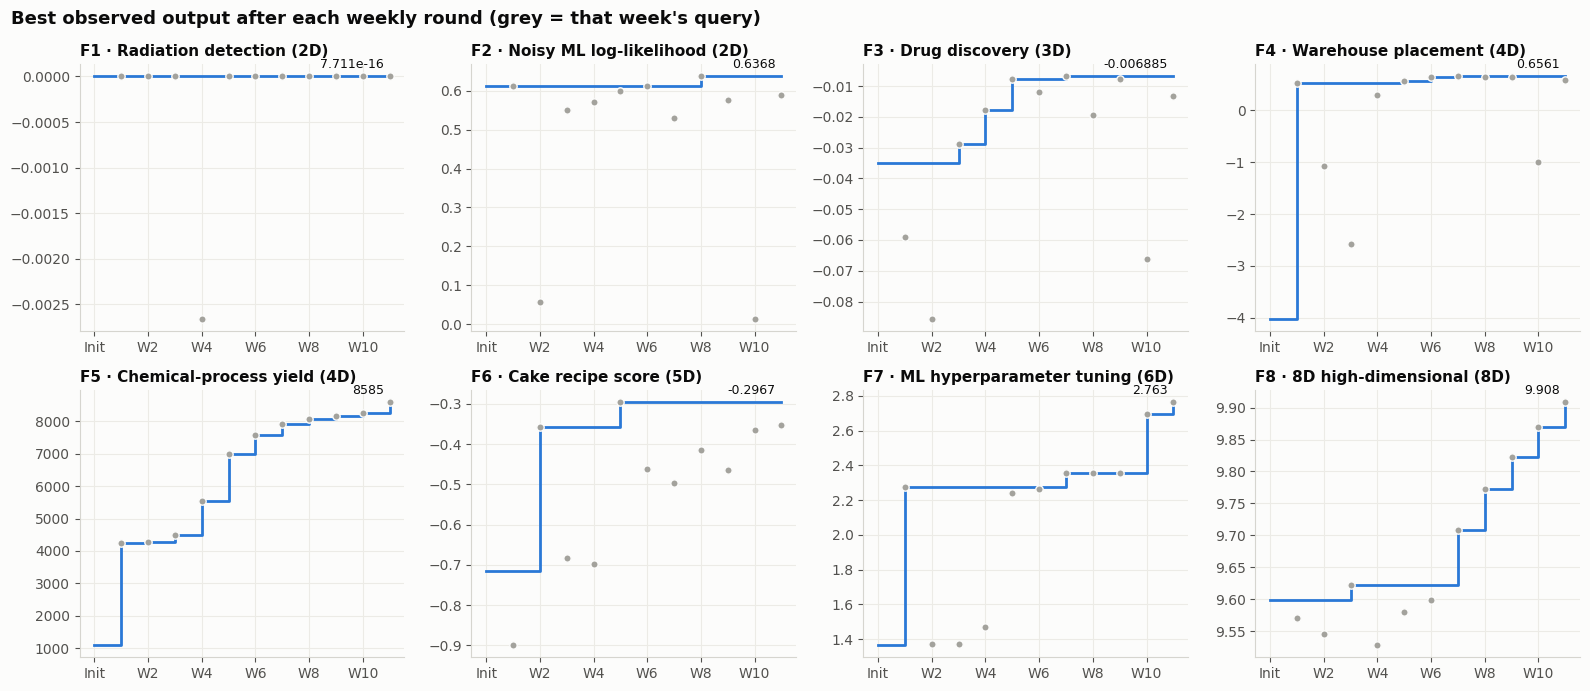

,Init,W1,W2,W3,W4,W5,W6,W7,W8,W9,W10,W11
F1,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16,7.7109e-16
F2,0.61121,0.61313,0.61313,0.61313,0.61313,0.61313,0.61356,0.61356,0.6368,0.6368,0.6368,0.6368
F3,-0.034835,-0.034835,-0.034835,-0.028715,-0.01775,-0.0076968,-0.0076968,-0.0068854,-0.0068854,-0.0068854,-0.0068854,-0.0068854
F4,-4.0255,0.52347,0.52347,0.52347,0.52347,0.56605,0.65018,0.65615,0.65615,0.65615,0.65615,0.65615
F5,"1,088.9","4,256.6","4,270.4","4,486.1","5,538.4","6,983.6","7,575.5","7,910.3","8,088.3","8,180.1","8,254.9","8,585.3"
F6,-0.71426,-0.71426,-0.35721,-0.35721,-0.35721,-0.29669,-0.29669,-0.29669,-0.29669,-0.29669,-0.29669,-0.29669
F7,1.365,2.2742,2.2742,2.2742,2.2742,2.2742,2.2742,2.355,2.357,2.357,2.6933,2.7625
F8,9.5985,9.5985,9.5985,9.622,9.622,9.622,9.622,9.7083,9.7718,9.8228,9.8691,9.908


In [3]:
best = pd.DataFrame({f"F{fn}": [load(fn, s)[1].max() for s in SNAPSHOTS] for fn in range(1, 9)},
                    index=["Init"] + [f"W{k}" for k in range(1, 12)])

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for fn, ax in zip(range(1, 9), axes.flat):
    X, y = load(fn)
    weekly = y[N0[fn]:]                        # one query per week, W1..W11
    wk = np.arange(1, len(weekly) + 1)
    ax.step(range(0, 12), best[f"F{fn}"].values, where="post", color=BLUE)
    lo = np.percentile(np.r_[y[:N0[fn]].max(), weekly], 5)   # clip catastrophic misses for readability
    ax.scatter(wk, np.clip(weekly, lo, None), s=28, color=GREY, zorder=3, edgecolor="#fcfcfb", linewidth=1)
    ax.set_title(f"F{fn} · {NAMES[fn]} ({X.shape[1]}D)", loc="left")
    ax.set_xticks(range(0, 12, 2)); ax.set_xticklabels(["Init"] + [f"W{k}" for k in range(2, 12, 2)])
    ax.annotate(f"{y.max():.4g}", (11, best[f'F{fn}'].iloc[-1]), xytext=(-4, 6),
                textcoords="offset points", ha="right", color=INK, fontsize=9)
fig.suptitle("Best observed output after each weekly round (grey = that week's query)", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "best_so_far.png", dpi=130, bbox_inches="tight"); plt.show()
best.T

**Reading the trajectories**

- **Strong, sustained climbers:** F5 (1,089 → 8,585, ×7.9), F8 (9.598 → 9.908, eight straight new bests), F7 (1.365 → 2.763).
- **One big jump, then refinement:** F4 went from −4.03 (all initial points negative) to +0.656 by tightening around its only positive region.
- **Converged early:** F2 (noise-dominated near 0.61–0.64), F3 (basin mapped at ≈ −0.0069), F6 (local optimum ≈ −0.297).
- **Flat:** F1 returned ≈ 0 for every query in 21 evaluations. Space-filling found no signal.

## 3. Method timeline

How the strategy for each function evolved (drawn from the weekly handovers in `docs/handovers/`).

| Fn | Weeks 1–3 | Weeks 4–6 | Weeks 7–11 | Why it changed |
|----|-----------|-----------|------------|----------------|
| F1 | GP UCB (κ=3–3.5) → space-filling | Maximin space-filling | Maximin | No signal at all; UCB is meaningless on a flat surface |
| F2 | GP UCB + WhiteKernel | GP EI, tight box | Re-confirm / centroid | Repeated near-identical queries varied by ±0.03, so the surface is noise-limited |
| F3 | GP (Matérn ½) + manual override | GP UCB | **Manual one-variable steps** | LOO showed a 10σ residual (a cliff); input warping tried and rejected |
| F4 | GP UCB | GP EI → **GP PI** in shrinking box | PI ±0.010–0.018, trust region on true best | Only one positive region; PI penalises straying from it |
| F5 | GP EI | **1D line search** on x1 | Boundary push to 0.999 | Clean monotone signal in x1; surrogate unnecessary |
| F6 | GP UCB | NN ensemble → Differential Evolution | Manual one-variable probes | Ensemble could not reproduce its own best training point (underfit in 5D) |
| F7 | GP UCB | NN ensemble → GP EI razor box | Manual x3 bisection → **trust-region GP UCB** | x3 is razor-sharp; trust region opened a new region in W10 (+0.336) |
| F8 | GP UCB + constraints | Bootstrap MLP ensemble UCB | **Trust-region GP UCB** (TuRBO-style) | Ensemble missed 3 weeks running; local GP was calibrated and predictive |

## 4. Toolkit

The same building blocks are used in every weekly script. They are collected here in clean form.

- **Surrogate:** `GaussianProcessRegressor` with a Matérn kernel (ARD length-scales) and an optional `WhiteKernel` noise term, `normalize_y=True`, 10 optimiser restarts.
- **Acquisitions:** UCB $\mu + \kappa\sigma$ (explore/exploit dial), EI (expected improvement), PI (probability of improvement, the most conservative).
- **Candidate search:** dense uniform random scan (≈100k points) inside a box. Using a **trust region** means the box is centred on the best observed point with small per-dimension half-widths.
- **Calibration check:** leave-one-out standardised residuals $z=(y-\mu_{-i})/\sigma_{-i}$. If $\max|z|>3$, the GP's uncertainty is not trusted.

In [4]:
def kern(d, ls, nu, noise=None):
    k = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[ls] * d, nu=nu)
    return k + WhiteKernel(noise, (1e-6, 1.0)) if noise else k

# Per-function kernels as used in the late-campaign scripts (src/weekly/week7_bo.py ... week10_bo.py)
KERNELS = {
    2: (lambda: C(1.0, (1e-3, 1e3)) * Matern([0.15, 0.10], nu=2.5) + WhiteKernel(0.02, (1e-4, 0.3)), 1e-6),
    3: (lambda: kern(3, 0.15, 0.5), 1e-6),
    4: (lambda: kern(4, 0.10, 1.5, 0.1), 1e-4),
    5: (lambda: kern(4, 0.30, 2.5, 1e-3), 1e-6),
    6: (lambda: kern(5, 0.20, 2.5, 0.05), 1e-6),
    7: (lambda: kern(6, 0.15, 1.5, 1e-3), 1e-5),
    8: (lambda: kern(8, 0.08, 2.5, 1e-3), 1e-5),
}

def fit_gp(X, y, kernel, alpha=1e-6, restarts=10):
    gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha, normalize_y=True,
                                  n_restarts_optimizer=restarts, random_state=0)
    return gp.fit(X, y)

def ucb(gp, Xc, kappa):
    mu, sd = gp.predict(Xc, return_std=True); return mu + kappa * sd

def ei(gp, Xc, y_best, xi=0.01):
    mu, sd = gp.predict(Xc, return_std=True); sd = np.maximum(sd, 1e-12)
    z = (mu - y_best - xi) / sd; return (mu - y_best - xi) * norm.cdf(z) + sd * norm.pdf(z)

def pi(gp, Xc, y_best, xi=0.005):
    mu, sd = gp.predict(Xc, return_std=True); return norm.cdf((mu - y_best - xi) / np.maximum(sd, 1e-12))

def trust_region(center, half, n=100_000, seed=0):
    lo, hi = np.clip(center - half, 0.005, 0.995), np.clip(center + half, 0.005, 0.995)
    return np.random.default_rng(seed).uniform(lo, hi, size=(n, len(center)))

def loo_z(X, y, kernel_fn, alpha):
    z = np.empty(len(y))
    for i in range(len(y)):
        m = np.arange(len(y)) != i
        gp = fit_gp(X[m], y[m], kernel_fn(), alpha, restarts=2)
        mu, sd = gp.predict(X[i:i+1], return_std=True)
        z[i] = (y[i] - mu[0]) / sd[0]
    return z

fmt = lambda q: " - ".join(f"{v:.6f}" for v in q)   # portal submission format

## 5. Worked example A — F8 trust-region GP (the campaign's best method)

F8 is 8-dimensional with only 51 points, far too few for a global GP to be reliable. Following the BBO-Challenge winners
(Turner et al., 2021; TuRBO, Eriksson et al., 2019), the search is restricted to a small box around the current best, where
the GP *is* locally accurate. This took F8 off a three-week plateau and produced a new best every week from W7 to W11.

In [5]:
X8, y8 = load(8)
kf, alpha = KERNELS[8]
gp8 = fit_gp(X8, y8, kf(), alpha)
best_x = X8[np.argmax(y8)]
half = np.array([0.012, 0.06, 0.025, 0.05, 0.06, 0.04, 0.05, 0.06])   # tight on the strong dims (x1, x3)
cand = trust_region(best_x, half, seed=8)
q8 = cand[np.argmax(ucb(gp8, cand, kappa=1.5))]
mu, sd = gp8.predict(q8[None], return_std=True)
print(f"Best observed F8  : {y8.max():.5f}")
print(f"Next query (UCB)  : {fmt(q8)}")
print(f"GP prediction     : {mu[0]:.4f} ± {sd[0]:.4f}")
print("Fitted kernel     :", gp8.kernel_)

Best observed F8  : 9.90803
Next query (UCB)  : 0.060723 - 0.153273 - 0.148421 - 0.095285 - 0.641682 - 0.706103 - 0.187811 - 0.824022
GP prediction     : 9.9419 ± 0.0064
Fitted kernel     : 19.7**2 * Matern(length_scale=[9.64, 13.2, 7.71, 14.2, 22, 13, 9.94, 1e+05], nu=2.5) + WhiteKernel(noise_level=1e-06)


## 6. Worked example B — F4, a hairline peak where PI beats EI and UCB

All 30 initial F4 points were negative (best −4.03). Once a single positive point was found, wide UCB/EI queries kept landing
in the catastrophic surroundings (e.g. −2.59 in W3, −0.995 in a W10 second-basin hunt). Probability of Improvement in a
shrinking box (±0.07 → ±0.010) climbed 0.524 → 0.566 → 0.650 → 0.656.

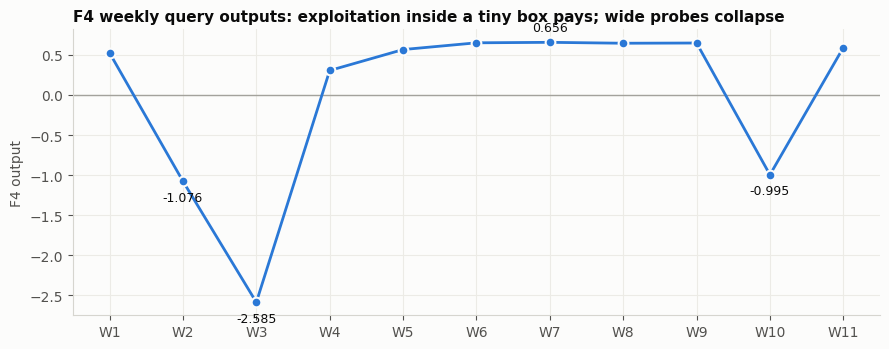

In [6]:
X4, y4 = load(4)
fig, ax = plt.subplots(figsize=(9, 3.6))
weekly = y4[N0[4]:]
ax.axhline(0, color=GREY, lw=1)
ax.plot(range(1, 12), weekly, color=BLUE, marker="o", ms=7, mec="#fcfcfb", mew=1.5)
for k, v in enumerate(weekly, 1):
    if v == y4.max() or v < -0.9:
        ax.annotate(f"{v:.3f}", (k, v), xytext=(0, 8 if v > 0 else -14), textcoords="offset points",
                    ha="center", fontsize=9, color=INK)
ax.set_xticks(range(1, 12)); ax.set_xticklabels([f"W{k}" for k in range(1, 12)])
ax.set_ylabel("F4 output"); ax.set_title("F4 weekly query outputs: exploitation inside a tiny box pays; wide probes collapse", loc="left")
fig.tight_layout(); fig.savefig(FIG / "f4_weekly.png", dpi=130, bbox_inches="tight"); plt.show()

## 7. Worked example C — F5, when you don't need a surrogate

F5 showed a clean monotone relationship: with x2–x4 held near 1, output rose steadily as x1 increased. A 1D line search
was more reliable than any surrogate, and pushing every dimension to the 0.999 boundary in W11 gave the final best of 8,585.

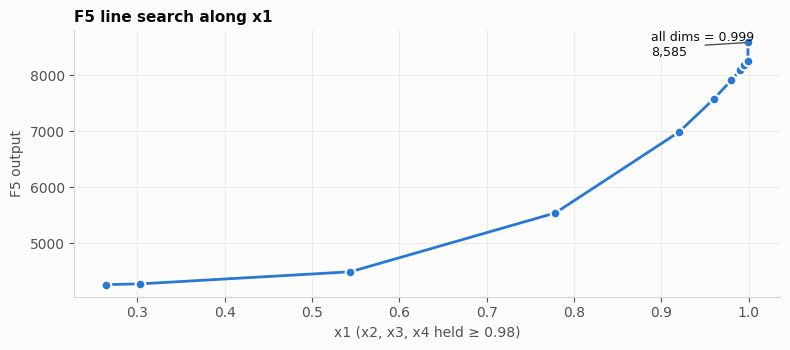

In [7]:
X5, y5 = load(5)
mask = (X5[:, 1:] > 0.98).all(axis=1)
order = np.argsort(X5[mask, 0])
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(X5[mask, 0][order], y5[mask][order], color=BLUE, marker="o", ms=7, mec="#fcfcfb", mew=1.5)
k = np.argmax(y5)
ax.annotate("all dims = 0.999\n8,585", (X5[k, 0], y5[k]), xytext=(-70, -10), textcoords="offset points",
            fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_xlabel("x1 (x2, x3, x4 held ≥ 0.98)"); ax.set_ylabel("F5 output")
ax.set_title("F5 line search along x1", loc="left")
fig.tight_layout(); fig.savefig(FIG / "f5_line_search.png", dpi=130, bbox_inches="tight"); plt.show()

## 8. Back-test — was the surrogate right *before* each query?

For each weekly query, refit the GP on **only the data available at that time** and predict the query's output.
This is an honest out-of-sample test of the surrogate, separate from whether the query improved the best.
I run it for the three GP-driven functions in the later campaign (F4, F7, F8), weeks 4–11.

In [8]:
bt = []
for fn in (4, 7, 8):
    X, y = load(fn); kf, alpha = KERNELS[fn]
    for wk in range(4, 12):
        i = N0[fn] + wk - 1                     # row index of week-wk query
        gp = fit_gp(X[:i], y[:i], kf(), alpha, restarts=3)
        mu, sd = gp.predict(X[i:i+1], return_std=True)
        bt.append({"Fn": f"F{fn}", "Week": wk, "Predicted": mu[0], "Std": sd[0], "Actual": y[i],
                   "z": (y[i] - mu[0]) / sd[0]})
bt = pd.DataFrame(bt)

summary = bt.groupby("Fn").apply(lambda g: pd.Series({
    "MAE": (g.Actual - g.Predicted).abs().mean(),
    "Within 2σ": f"{(g.z.abs() <= 2).sum()}/{len(g)}",
    "Spearman ρ (pred vs actual)": g[["Predicted", "Actual"]].corr("spearman").iloc[0, 1]}))
summary

,MAE,Within 2σ,Spearman ρ (pred vs actual)
Fn,,,
F4,0.15105,8/8,0.64286
F7,0.083797,6/8,0.85714
F8,0.023658,7/8,0.90476


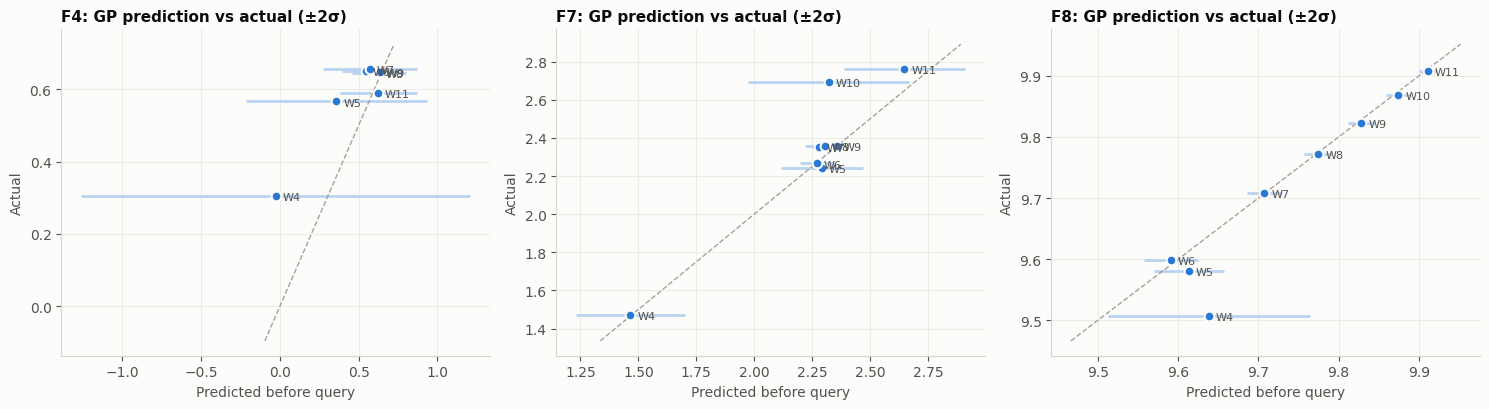

,Fn,Week,Predicted,Std,Actual,z
16,F8,4,9.6383,0.0629,9.507,-2.0892
17,F8,5,9.6134,0.0219,9.5807,-1.4897
18,F8,6,9.5915,0.0168,9.599,0.4483
19,F8,7,9.7073,0.011,9.7083,0.0891
20,F8,8,9.7747,0.0087,9.7718,-0.33
21,F8,9,9.8282,0.0086,9.8228,-0.6274
22,F8,10,9.8743,0.0077,9.8691,-0.6798
23,F8,11,9.9113,0.0054,9.908,-0.6075


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, fn in zip(axes, ("F4", "F7", "F8")):
    g = bt[bt.Fn == fn]
    if fn == "F4":
        g = g[g.Actual > -0.5]   # drop the W10 −0.995 deliberate exploration probe for scale
    ax.errorbar(g.Predicted, g.Actual, xerr=2 * g.Std, fmt="o", color=BLUE, ecolor="#b9d3f2",
                ms=7, mec="#fcfcfb", mew=1.5, capsize=0)
    lo, hi = min(g.Predicted.min(), g.Actual.min()), max(g.Predicted.max(), g.Actual.max())
    pad = (hi - lo) * 0.1; ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=GREY, lw=1, ls="--")
    for _, r in g.iterrows():
        ax.annotate(f"W{int(r.Week)}", (r.Predicted, r.Actual), xytext=(5, -3), textcoords="offset points", fontsize=8, color=MUTED)
    ax.set_title(f"{fn}: GP prediction vs actual (±2σ)", loc="left"); ax.set_xlabel("Predicted before query"); ax.set_ylabel("Actual")
fig.tight_layout(); fig.savefig(FIG / "backtest_calibration.png", dpi=130, bbox_inches="tight"); plt.show()
bt[bt.Fn == "F8"].round(4)

**Reading the back-test.** F8's local GP was the best-calibrated model in the campaign. Its predictions track the actual outcomes
closely, which is why I kept trusting it. F4 and F7 are less precise (sharp peaks), which is why their boxes were kept very tight
and why several F7 steps were manual.

## 9. Calibration diagnostic on the final data (LOO)

A standing weekly check from W7 onward. A well-specified GP gives $z \sim N(0,1)$, so std ≈ 1 and no $|z| > 3$.

In [10]:
loo = []
for fn in range(2, 9):
    X, y = load(fn); kf, alpha = KERNELS[fn]
    z = loo_z(X, y, kf, alpha)
    loo.append({"Fn": f"F{fn}", "n": len(y), "std(z)": z.std(), "max|z|": np.abs(z).max(),
                "Trust GP uncertainty?": "yes" if np.abs(z).max() <= 3 else "no — act locally"})
pd.DataFrame(loo).set_index("Fn")

,n,std(z),max|z|,Trust GP uncertainty?
Fn,,,,
F2,21,1.1603,2.5311,yes
F3,26,4.0946,17.826,no — act locally
F4,41,0.76019,2.7094,yes
F5,31,1.5729,6.8213,no — act locally
F6,31,1.6465,3.8202,no — act locally
F7,41,0.93501,4.4048,no — act locally
F8,51,0.86156,2.1974,yes


## 10. Noise check — F2

Essentially the same point (within 0.001 of (0.717, 0.969)) was submitted four times (W6, W8, W9, W11):

In [11]:
X2, y2 = load(2)
rep = np.isclose(X2, [0.717, 0.9691], atol=1e-3).all(axis=1)
print("Repeated outputs:", np.round(y2[rep], 4), f"→ std ≈ {y2[rep].std(ddof=1):.3f}")
print(f"Mean of repeats ≈ {y2[rep].mean():.3f}: the 0.6368 best is partly a lucky noise draw.")

Repeated outputs: [0.6136 0.6368 0.5751 0.5879] → std ≈ 0.027
Mean of repeats ≈ 0.603: the 0.6368 best is partly a lucky noise draw.


## 11. Final results

In [12]:
final = []
for fn in range(1, 9):
    X, y = load(fn); j = np.argmax(y)
    final.append({"Fn": f"F{fn}", "Dim": X.shape[1], "Queries": len(y) - N0[fn], "Initial best": y[:N0[fn]].max(),
                  "Final best": y[j], "Best x": "(" + ", ".join(f"{v:.3f}" for v in X[j]) + ")"})
pd.DataFrame(final).set_index("Fn")

,Dim,Queries,Initial best,Final best,Best x
Fn,,,,,
F1,2,11,7.7109e-16,7.7109e-16,"(0.731, 0.733)"
F2,2,11,0.61121,0.6368,"(0.717, 0.969)"
F3,3,11,-0.034835,-0.0068854,"(0.466, 0.490, 0.426)"
F4,4,11,-4.0255,0.65615,"(0.396, 0.418, 0.359, 0.414)"
F5,4,11,"1,088.9","8,585.3","(0.999, 0.999, 0.999, 0.999)"
F6,5,11,-0.71426,-0.29669,"(0.325, 0.349, 0.446, 0.770, 0.010)"
F7,6,11,1.365,2.7625,"(0.007, 0.164, 0.530, 0.306, 0.334, 0.702)"
F8,8,11,9.5985,9.908,"(0.063, 0.184, 0.139, 0.114, 0.582, 0.745, 0.1..."


## 12. Lessons

1. **Match the method to the surface, not the other way round.** No single surrogate won everywhere. GP+UCB was a good start,
   but the biggest gains came from switching method per function (PI for F4, line search for F5, trust region for F7/F8).
2. **Go local when data is scarce.** With 20–50 points in 4–8 dimensions, a global GP is overconfident somewhere. Trust regions
   kept every prediction inside the zone where the model had evidence.
3. **Measure calibration, don't assume it.** The LOO check flagged F3 and F7 as untrustworthy and justified manual
   steps there. Back-tests showed F8's GP could be trusted.
4. **Spend queries by marginal return.** In the endgame, converged functions (F1, F2, F3, F6) got re-confirmation queries, while the
   functions still climbing (F5, F7, F8) got the effort.
5. **What I'd do differently:** add input/output transforms early (log for F1, rank-based for F4), keep a fixed
   exploration budget from week 1 instead of re-deciding weekly, and run the back-test from the start to pick surrogates
   on evidence.